# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
aviation_df = pd.read_csv("Aviation_Cleaned.csv")

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# Mask Aircraft.Size to True or False depending on Number.of.Passengers >= 20, and then replace with "Large" and "Small" label.
aviation_df["Aircraft.Size"] = aviation_df["Number.of.Passengers"] >= 20
aviation_df["Aircraft.Size"] = aviation_df["Aircraft.Size"].replace([True, False], ["Large", "Small"])

# Separate plane types into different dataframes.
small_df = aviation_df[aviation_df["Aircraft.Size"] == "Small"]
large_df = aviation_df[aviation_df["Aircraft.Size"] == "Large"]

print(f"The dataset contains {len(small_df)} small airplanes and {len(large_df)} large airplanes.")

The dataset contains 63216 small airplanes and 1408 large airplanes.


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

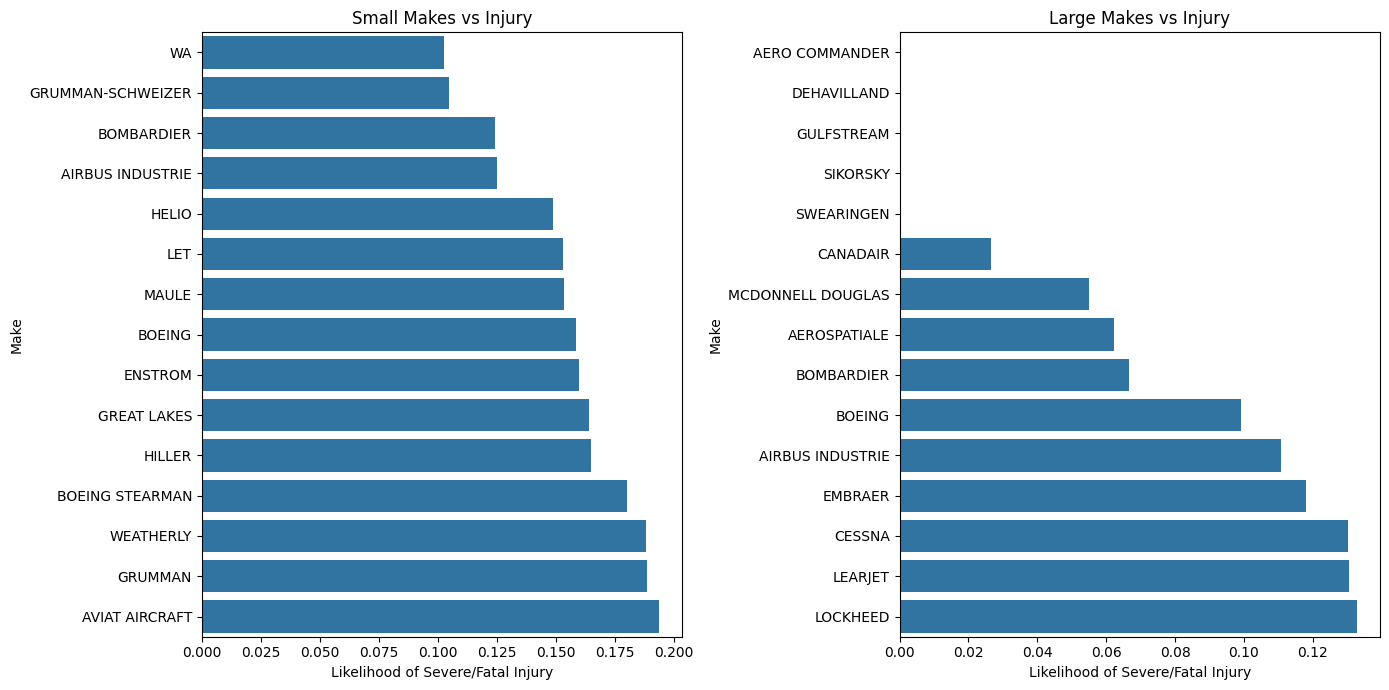

In [4]:
small_means = small_df.loc[:, ["Make", "Severity.Likelihood"]].groupby("Make")["Severity.Likelihood"].mean().nsmallest(15)

large_means = large_df.loc[:, ["Make", "Severity.Likelihood"]].groupby("Make")["Severity.Likelihood"].mean().nsmallest(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

barplot1 = sns.barplot(x=small_means.values, y=small_means.index, ax=ax1)
barplot1.set(title="Small Makes vs Injury", xlabel="Likelihood of Severe/Fatal Injury")

barplot2 = sns.barplot(x=large_means.values, y=large_means.index, ax=ax2)
barplot2.set(title="Large Makes vs Injury", xlabel="Likelihood of Severe/Fatal Injury")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

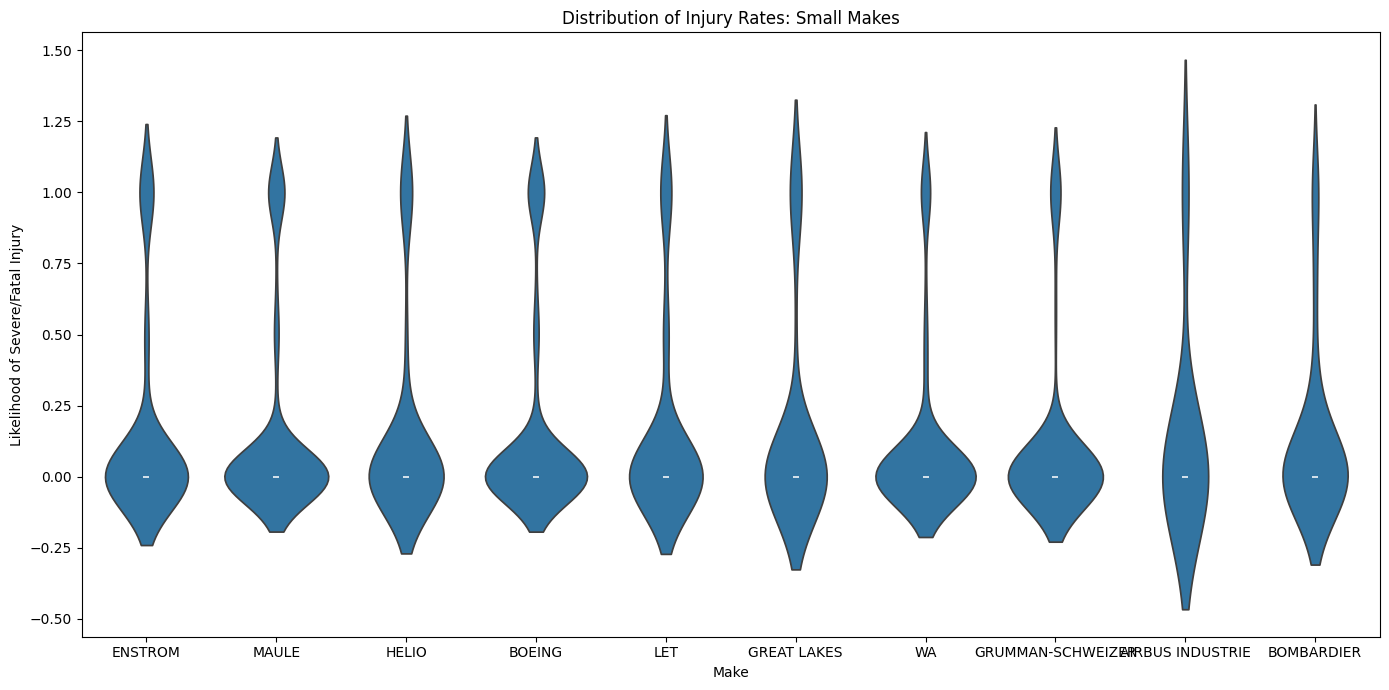

In [5]:
filtered_makes = small_means.nsmallest(10).index

filtered_df = small_df[small_df["Make"].isin(filtered_makes)]

fig, ax = plt.subplots(figsize=(14, 7))

sns.violinplot(data=filtered_df, x="Make", y="Severity.Likelihood")
ax.set(title="Distribution of Injury Rates: Small Makes", ylabel="Likelihood of Severe/Fatal Injury")

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

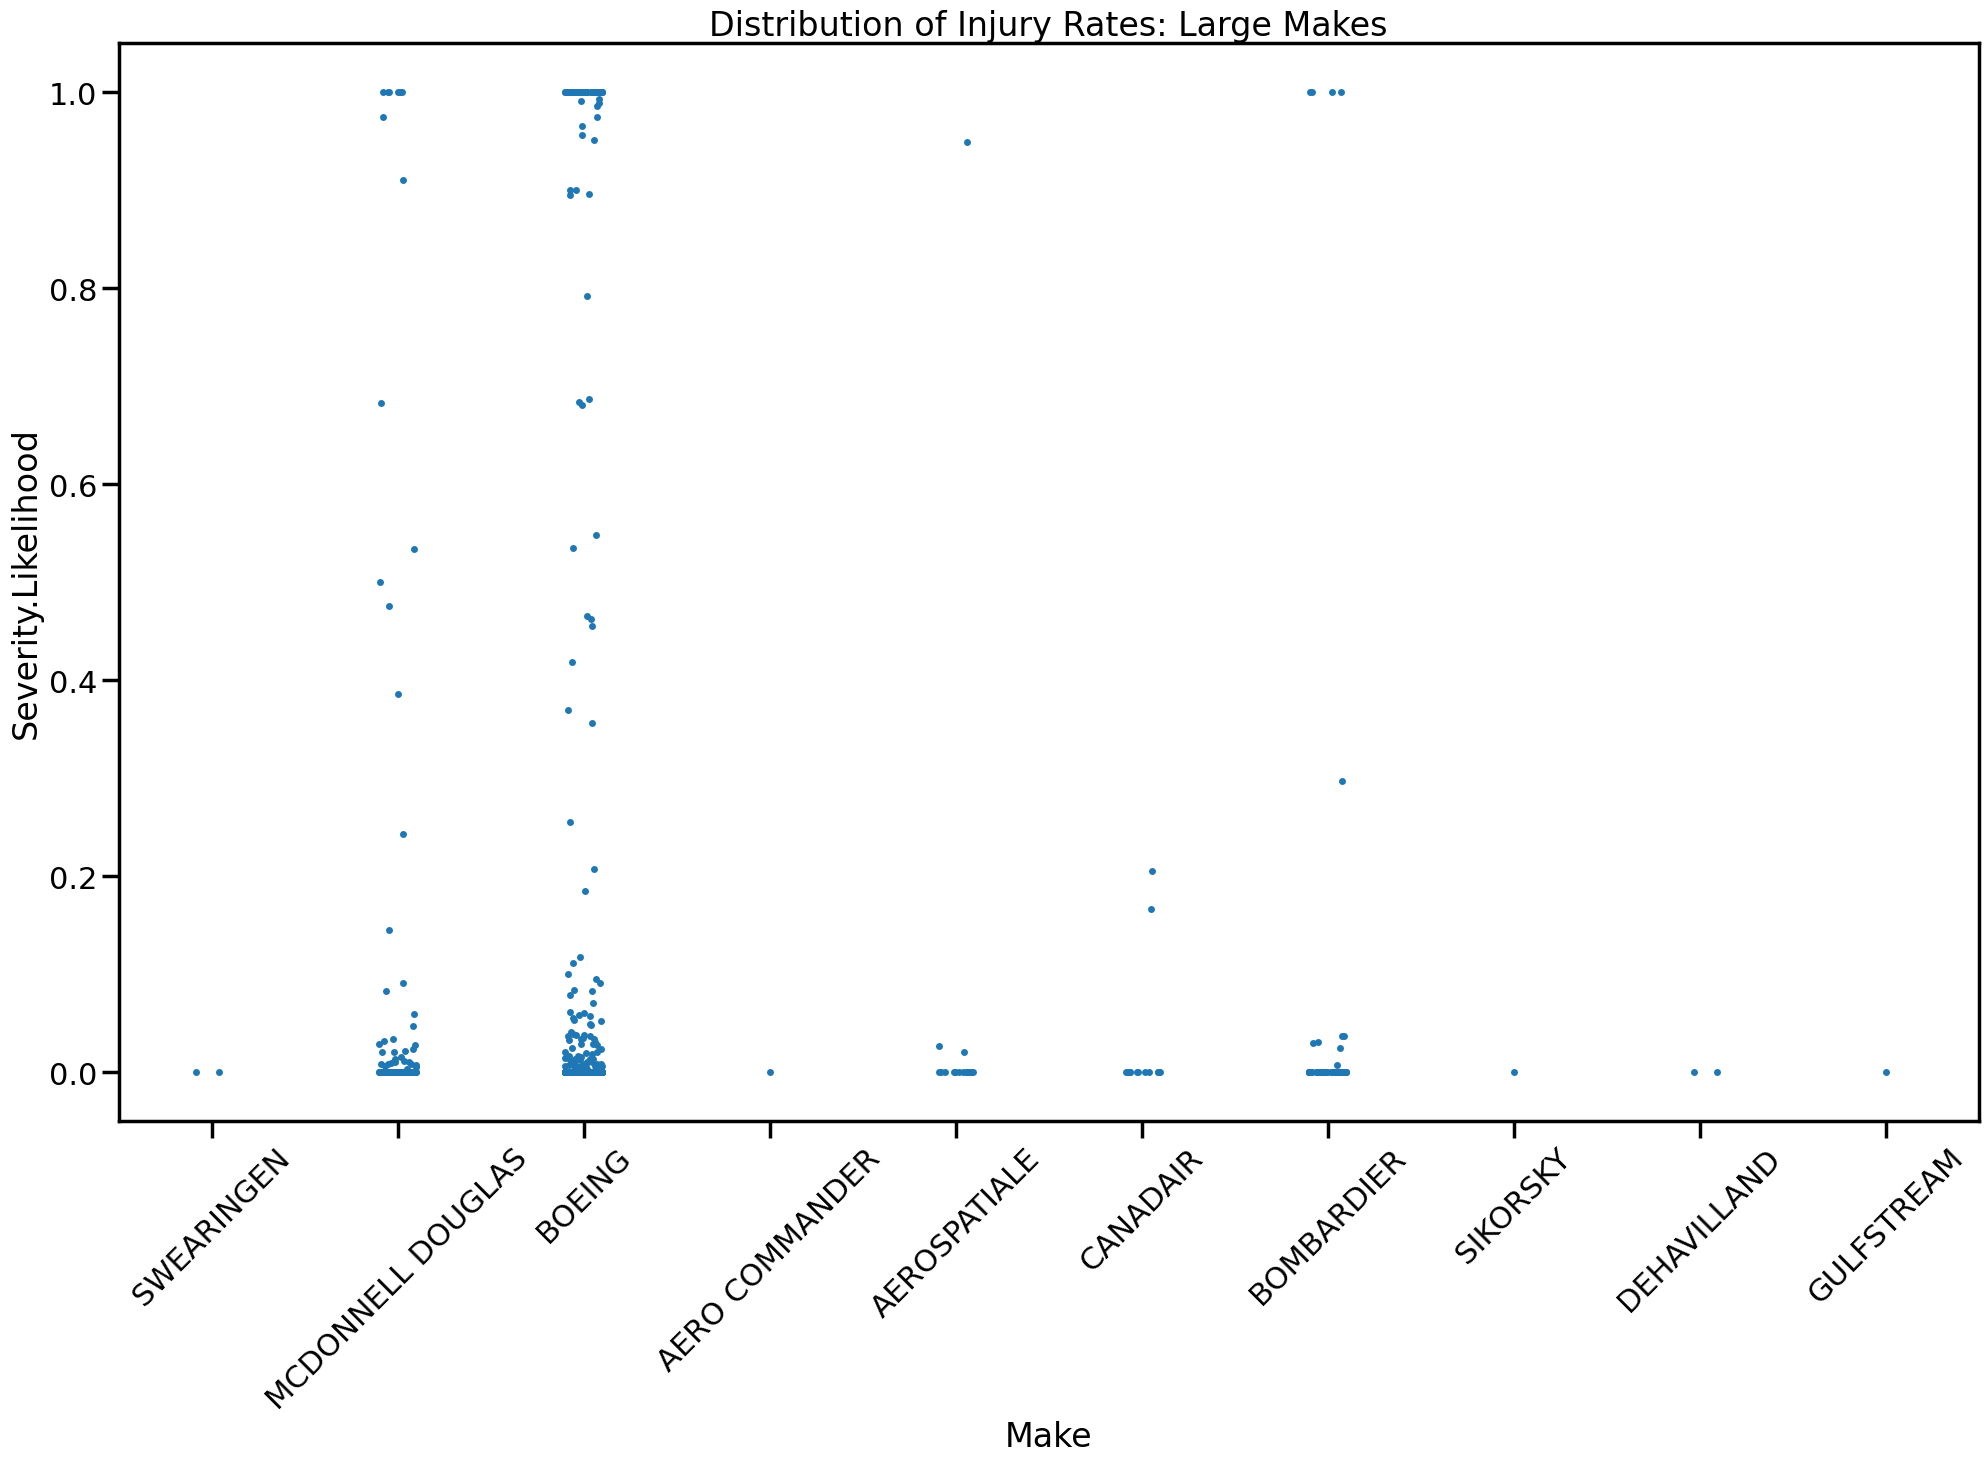

In [31]:
filtered_makes = large_means.nsmallest(10).index

filtered_df = large_df[large_df["Make"].isin(filtered_makes)]

fig, ax = plt.subplots(figsize=(24, 14))

sns.stripplot(data=filtered_df, x="Make", y="Severity.Likelihood")
ax.set(title="Distribution of Injury Rates: Large Makes")
ax.tick_params(axis='x', rotation=45)

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

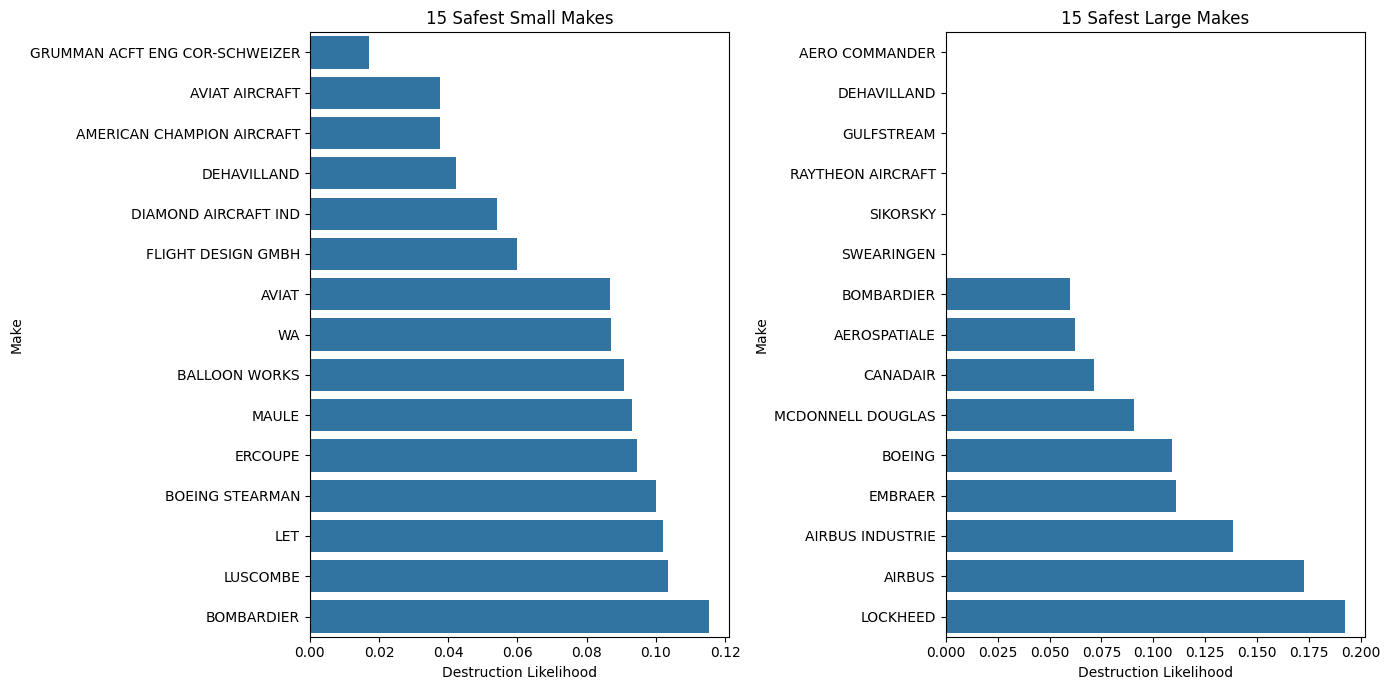

In [7]:
small_destruction_means = small_df.groupby("Make")["Aircraft.Destroyed"].mean().nsmallest(15)
large_destruction_means = large_df.groupby("Make")["Aircraft.Destroyed"].mean().nsmallest(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

barplot3 = sns.barplot(x=small_destruction_means.values, y=small_destruction_means.index, ax=ax1)
barplot3.set(title="15 Safest Small Makes",xlabel="Destruction Likelihood")

barplot4 = sns.barplot(x=large_destruction_means.values, y=large_destruction_means.index, ax=ax2)
barplot4.set(title="15 Safest Large Makes",xlabel="Destruction Likelihood")

plt.tight_layout()
plt.show()

In [8]:
# Summary statistics for makes: injury rate and destruction rate with sample sizes
small_make_summary = small_df.groupby("Make").agg(
    Mean_Injury_Rate=("Severity.Likelihood", "mean"),
    Std_Injury_Rate=("Severity.Likelihood", "std"),
    Mean_Destruction_Rate=("Aircraft.Destroyed", "mean"),
    N_Accidents=("Severity.Likelihood", "count")
).round(3)

large_make_summary = large_df.groupby("Make").agg(
    Mean_Injury_Rate=("Severity.Likelihood", "mean"),
    Std_Injury_Rate=("Severity.Likelihood", "std"),
    Mean_Destruction_Rate=("Aircraft.Destroyed", "mean"),
    N_Accidents=("Severity.Likelihood", "count")
).round(3)

print("Top 10 Safest Small Aircraft Makes (by mean injury rate):")
display(small_make_summary.nsmallest(10, "Mean_Injury_Rate"))

print("\nTop 10 Safest Large Aircraft Makes (by mean injury rate):")
display(large_make_summary.nsmallest(10, "Mean_Injury_Rate"))

Top 10 Safest Small Aircraft Makes (by mean injury rate):


,Mean_Injury_Rate,Std_Injury_Rate,Mean_Destruction_Rate,N_Accidents
Make,,,,
WA,0.103,0.284,0.087,138
GRUMMAN-SCHWEIZER,0.104,0.301,0.254,126
BOMBARDIER,0.124,0.297,0.115,26
AIRBUS INDUSTRIE,0.125,0.354,0.125,8
HELIO,0.149,0.343,0.123,106
LET,0.153,0.340,0.102,98
MAULE,0.153,0.344,0.093,569
BOEING,0.158,0.345,0.124,573
ENSTROM,0.160,0.351,0.156,211



Top 10 Safest Large Aircraft Makes (by mean injury rate):


,Mean_Injury_Rate,Std_Injury_Rate,Mean_Destruction_Rate,N_Accidents
Make,,,,
AERO COMMANDER,0.000,NaN,0.000,1
DEHAVILLAND,0.000,0.000,0.000,2
GULFSTREAM,0.000,NaN,0.000,1
SIKORSKY,0.000,NaN,0.000,1
SWEARINGEN,0.000,0.000,0.000,2
CANADAIR,0.027,0.068,0.071,14
MCDONNELL DOUGLAS,0.055,0.204,0.091,209
AEROSPATIALE,0.062,0.237,0.062,16
BOMBARDIER,0.067,0.240,0.060,67


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

**Small Aircraft:**
Among small aircraft makes, the safeset makes show injury rates clustered near zero, meaning the majority of recorded accidents for these manufacturers produced no serious passenger harm. Makes such as WA and GRUMMAN-SCHWEIZER can be confidently recommended due to the higher accident sample size (`N_Accidents`) and low injury and destruction rates. However, large aircrafts have even lower injury/destruction rates, with even more samples.

**Large Aircraft:**
The large aircraft sample is considerably smaller (~800 incidents vs. ~47,000 for small), so results require more caution. Major commercial manufacturers consistently show low injury and destruction rates. The strip plot distributions for large makes tend to have a lower variance than small aircraft, meaning that the outcome is more consistent. Both BOEING and MCDONNELL DOUGLAS have much lower injury likelihood than any small makes, and have many more data points.

**Recommendation for Client:**
BOEING is the best recommendation. It has an incredibly low injury rate and destruction rate. Since it has 734 data points, these flights are well documented and the data is consistent.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

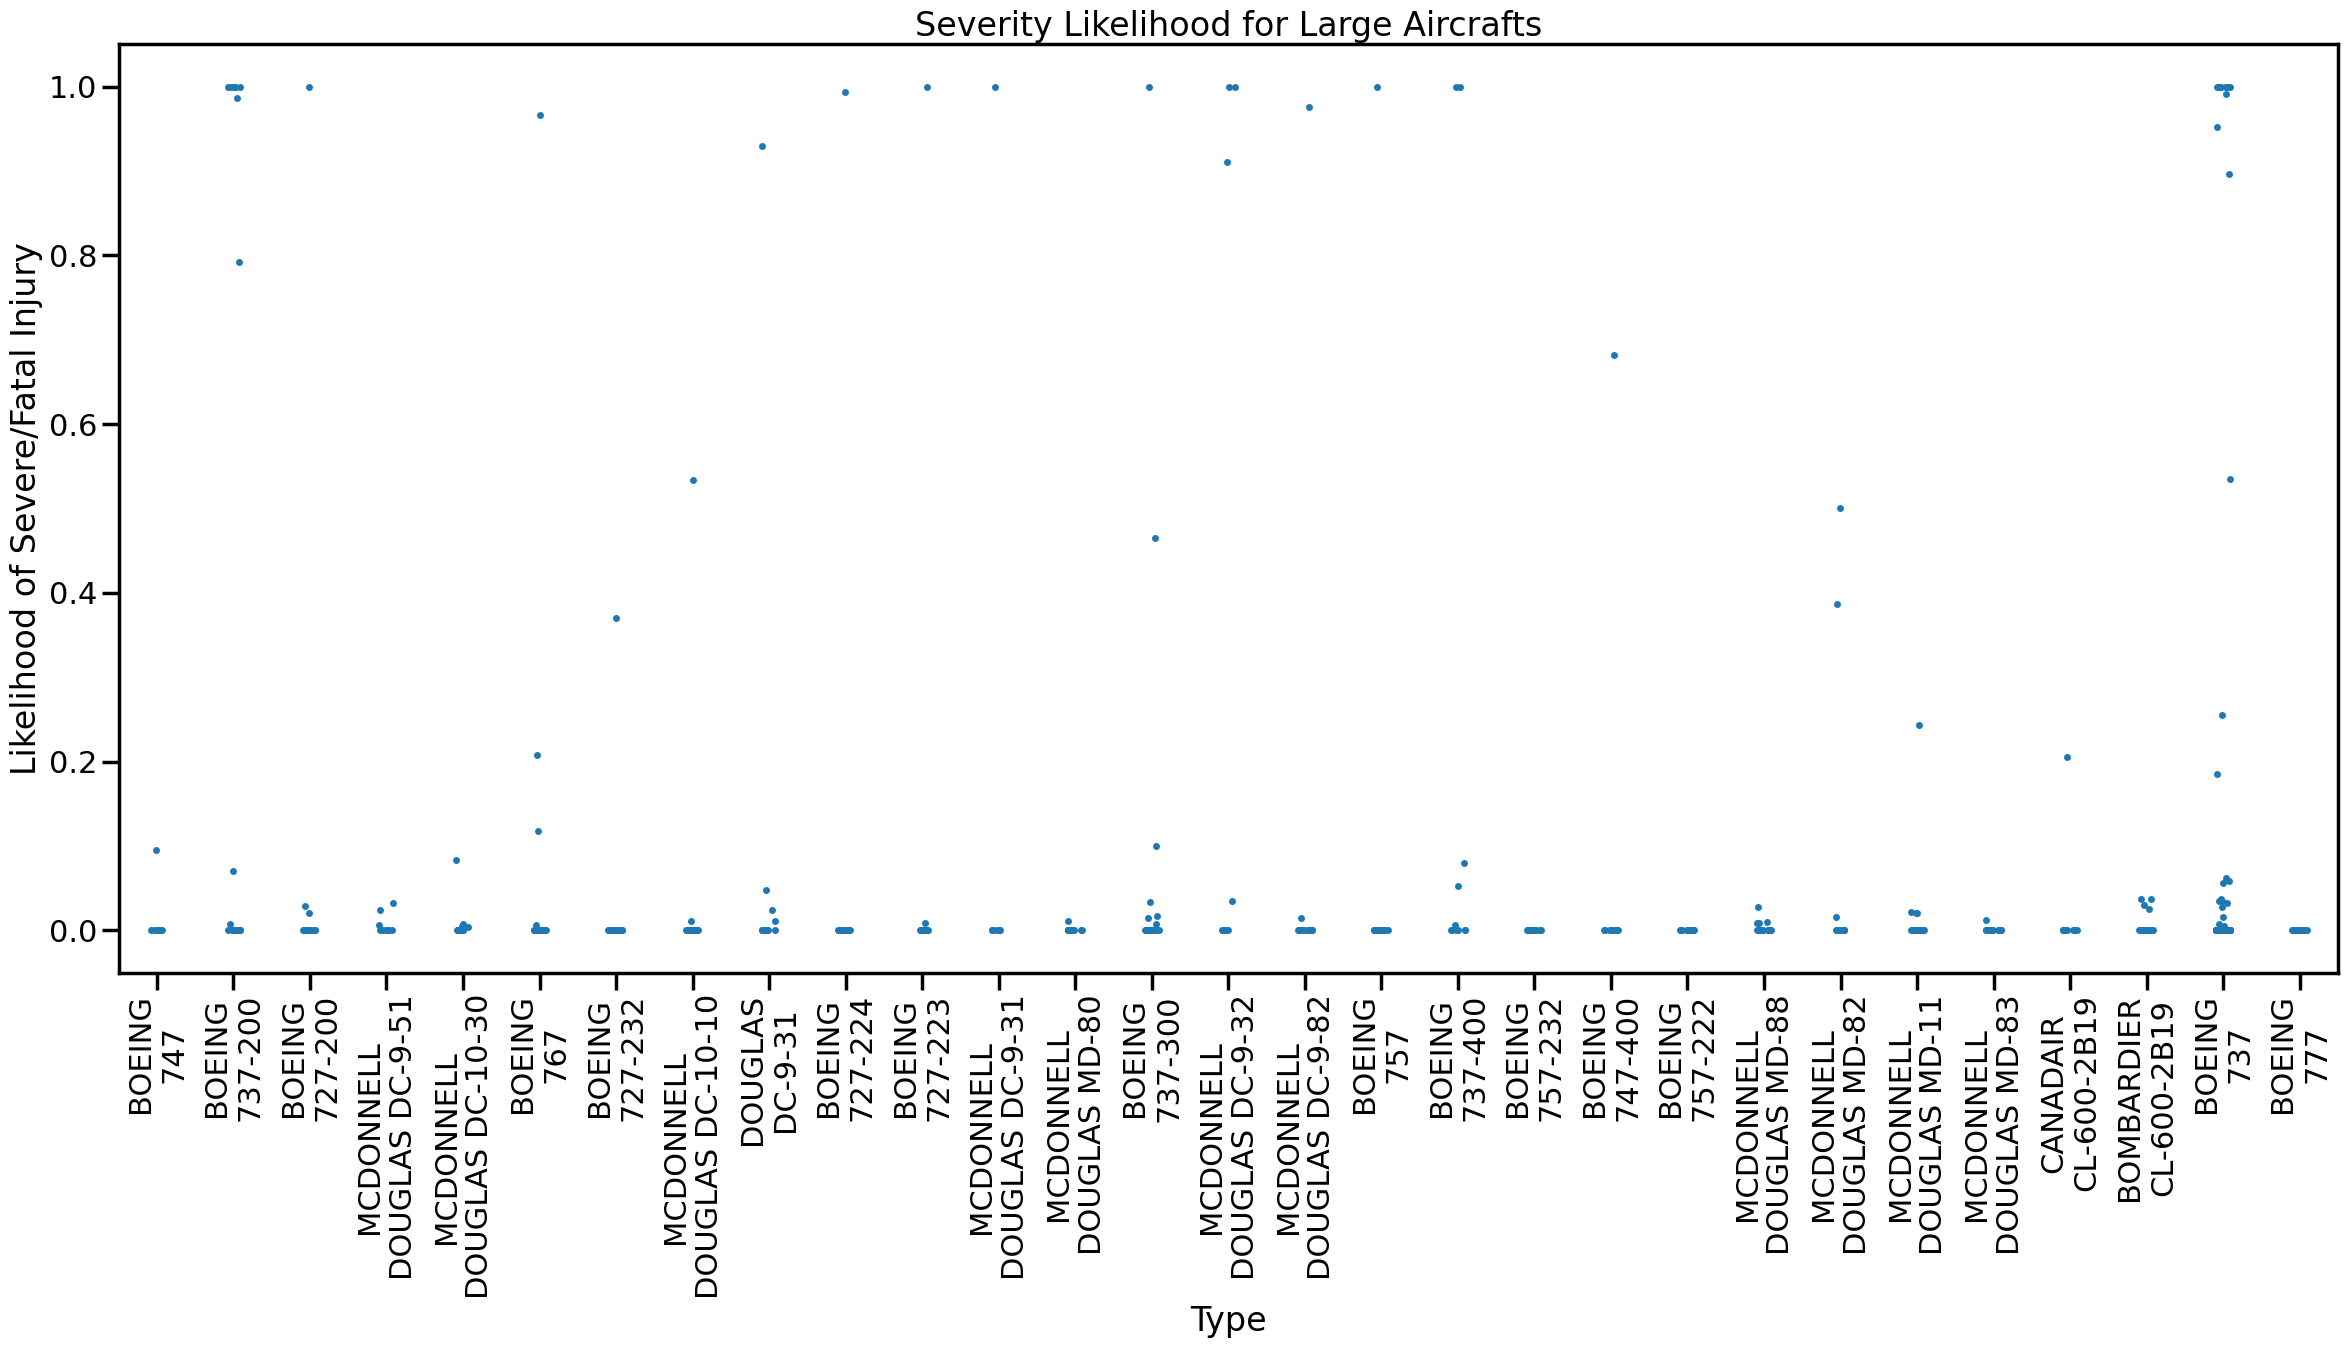

In [26]:
large_type_counts = large_df["Aircraft.Type"].value_counts()
filtered_df = large_df[large_df["Aircraft.Type"].map(large_type_counts) >= 10]

fig, ax = plt.subplots(figsize=(24, 14))

sns.stripplot(data=filtered_df, x="Aircraft.Type", y="Severity.Likelihood")
ax.set(title="Severity Likelihood for Large Aircrafts", xlabel="Type", ylabel="Likelihood of Severe/Fatal Injury")

# Use newline to separate Model and Make on x-axis ticks
locs, labels = plt.xticks()
new_labels = [label.get_text().replace(' ', '\n', 1) for label in labels]
plt.xticks(locs, new_labels)
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics for large aircraft types with at least 10 recorded accidents
large_type_summary = (
    large_df.groupby("Aircraft.Type")
    .agg(
        Mean_Injury_Rate=("Severity.Likelihood", "mean"),
        Std_Injury_Rate=("Severity.Likelihood", "std"),
        Mean_Destruction_Rate=("Aircraft.Destroyed", "mean"),
        N_Accidents=("Severity.Likelihood", "count")
    )
    .query("N_Accidents >= 10")
    .sort_values("Mean_Injury_Rate")
    .round(3)
)

print("Safest Large Aircraft Types:")
display(large_type_summary.head(10))

Safest Large Aircraft Types:


,Mean_Injury_Rate,Std_Injury_Rate,Mean_Destruction_Rate,N_Accidents
Aircraft.Type,,,,
BOEING 777,0.000,0.000,0.056,18
BOEING 757-232,0.000,0.000,0.000,10
BOEING 757-222,0.000,0.000,0.000,10
MCDONNELL DOUGLAS MD-83,0.001,0.003,0.077,13
MCDONNELL DOUGLAS MD-80,0.001,0.003,0.000,11
MCDONNELL DOUGLAS MD-88,0.003,0.007,0.000,17
MCDONNELL DOUGLAS DC-9-51,0.006,0.011,0.091,11
BOMBARDIER CL-600-2B19,0.006,0.013,0.000,22
MCDONNELL DOUGLAS DC-10-30,0.008,0.024,0.083,12


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

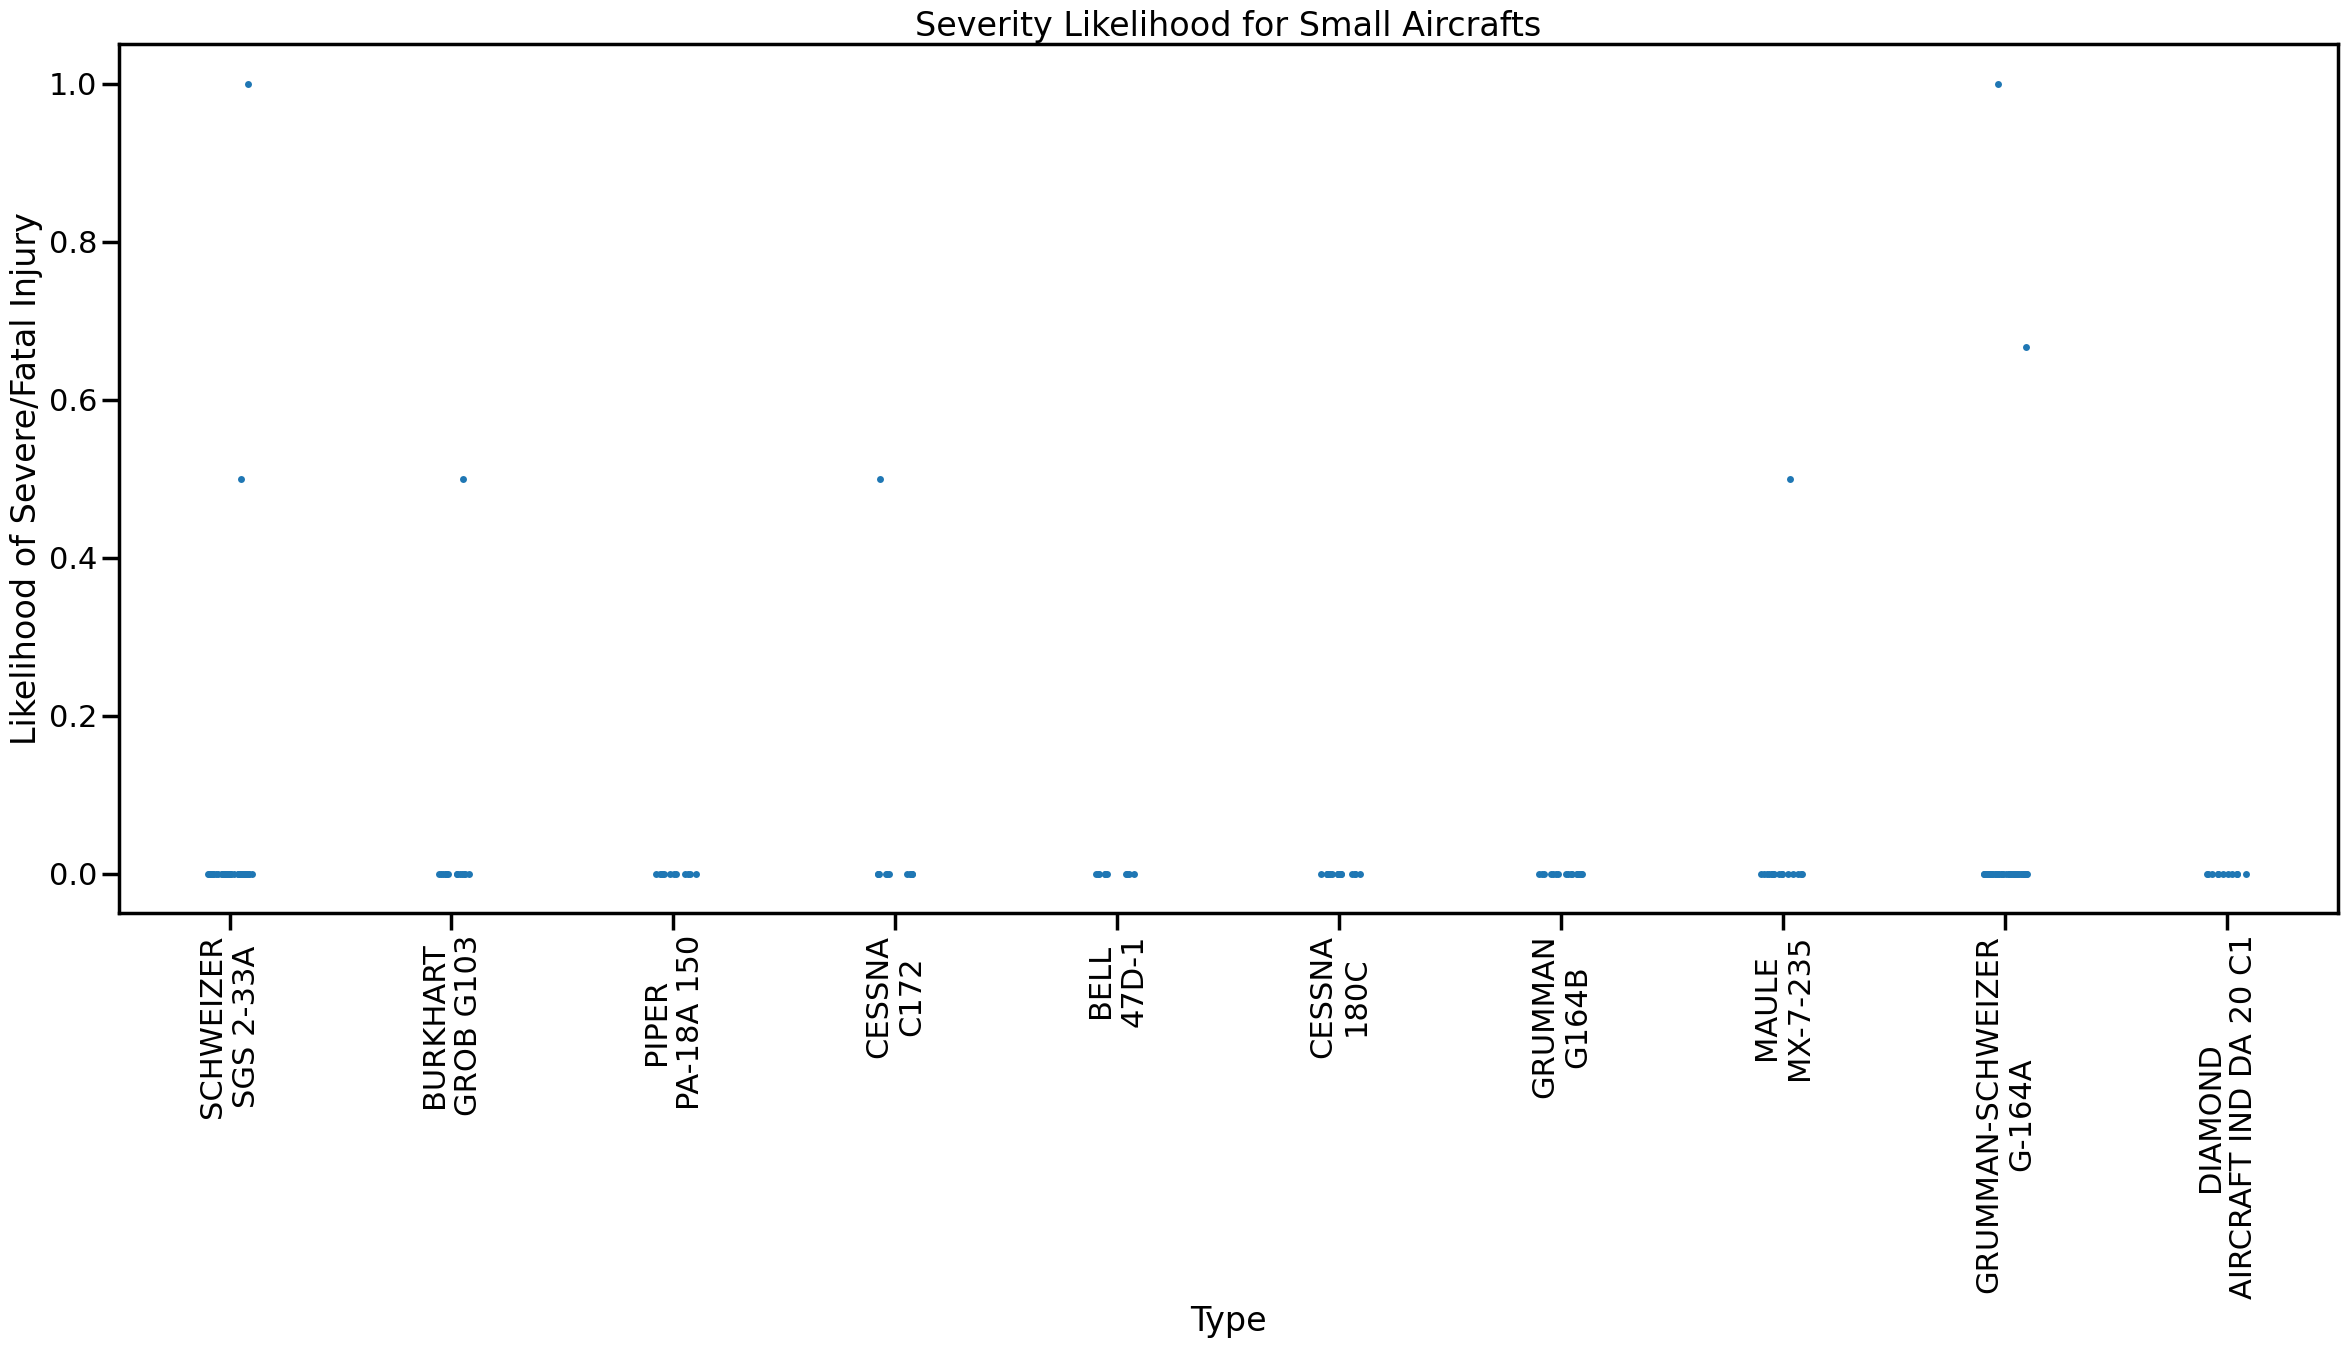

In [29]:
small_type_counts = small_df["Aircraft.Type"].value_counts()
# Filter to types with at least 10 examples, then identify 10 with lowest mean injury rate
valid_small_types = small_type_counts[small_type_counts >= 10].index
filtered_df = small_df[small_df["Aircraft.Type"].isin(valid_small_types)]
top10_small_types = filtered_df.groupby("Aircraft.Type")["Severity.Likelihood"].mean().nsmallest(10).index
filtered_df = filtered_df[filtered_df["Aircraft.Type"].isin(top10_small_types)]

fig, ax = plt.subplots(figsize=(24, 14))

sns.set_context('poster')
sns.stripplot(data=filtered_df, x="Aircraft.Type", y="Severity.Likelihood")
ax.set(title="Severity Likelihood for Small Aircrafts", xlabel="Type", ylabel="Likelihood of Severe/Fatal Injury")

# Use newline to separate Model and Make on x-axis ticks
locs, labels = plt.xticks()
new_labels = [label.get_text().replace(' ', '\n', 1) for label in labels]
plt.xticks(locs, new_labels)
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [12]:
# Summary statistics for small aircraft types with at least 10 recorded accidents
small_type_summary = (
    small_df.groupby("Aircraft.Type")
    .agg(
        Mean_Injury_Rate=("Severity.Likelihood", "mean"),
        Std_Injury_Rate=("Severity.Likelihood", "std"),
        Mean_Destruction_Rate=("Aircraft.Destroyed", "mean"),
        N_Accidents=("Severity.Likelihood", "count")
    )
    .query("N_Accidents >= 10")
    .nsmallest(10, "Mean_Injury_Rate")
    .round(3)
)

print("10 Safest Small Aircraft Types:")
display(small_type_summary)

10 Safest Small Aircraft Types:


,Mean_Injury_Rate,Std_Injury_Rate,Mean_Destruction_Rate,N_Accidents
Aircraft.Type,,,,
BELL 47D-1,0.000,0.000,0.000,10
CESSNA 180C,0.000,0.000,0.067,15
DIAMOND AIRCRAFT IND DA 20 C1,0.000,0.000,0.000,11
GRUMMAN G164B,0.000,0.000,0.062,16
PIPER PA-18A 150,0.000,0.000,0.000,12
MAULE MX-7-235,0.029,0.121,0.000,17
BURKHART GROB G103,0.033,0.129,0.000,15
SCHWEIZER SGS 2-33A,0.033,0.165,0.044,45
GRUMMAN-SCHWEIZER G-164A,0.034,0.170,0.163,49


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

**Large Aircraft Types:**
Individual airplane types is a less reliable measure, as the number of accidents is significantly smaller. Even so, most of the patterns are consistent here as they were when comparing makes, as large aircrafts still appear more safe. Additionally, BOEING and MCDONNELL make up most of the top 10, which aligns with the safest makes. Some rows have 0% injury rate and 0% deviation with 10+ accidents, which increases confidence.

**Small Aircraft Types:**
While BOEING and MCDONNELL appeared consistently in large aircraft types, small aircraft types have no consistently safe make. That said, the top 10 small aircraft types have similar injury rates, destructions rates, and deviation as the large aircraft types, indicating that the safest small aircrafts are as safe as the safest large aircrafts.

**Recommendation for Client:**
BOEING continues to be the recommendation, as its low injury rate and low destruction rate persists across different models, making it a good all-around pick. For a small aircraft, there is no consistently safe make, but specific types are just as safe, such as the BELL 47D-1.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Factor 1: Weather Condition

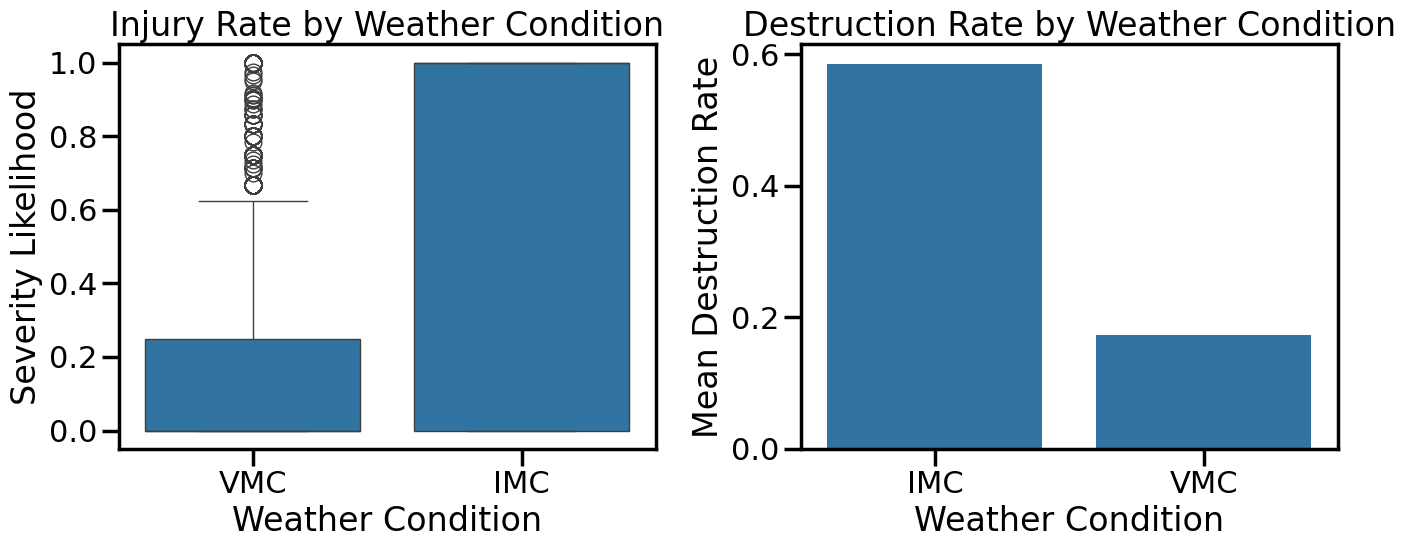

In [15]:
# Filter to known weather conditions (VMC = Visual, IMC = Instrument)
weather_df = aviation_df[aviation_df["Weather.Condition"].isin(["VMC", "IMC"])].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=weather_df, x="Weather.Condition", y="Severity.Likelihood", ax=ax1)
ax1.set(title="Injury Rate by Weather Condition",
        xlabel="Weather Condition",
        ylabel="Severity Likelihood")

dest_means = weather_df.groupby("Weather.Condition")["Aircraft.Destroyed"].mean().reset_index()
sns.barplot(data=dest_means, x="Weather.Condition", y="Aircraft.Destroyed", ax=ax2)
ax2.set(title="Destruction Rate by Weather Condition",
        xlabel="Weather Condition",
        ylabel="Mean Destruction Rate")

plt.tight_layout()
plt.show()

**Weather Condition: Findings**

Weather is recorded as VMC (Visual Meteorological Conditions — clear/good visibility) or IMC (Instrument Meteorological Conditions — low visibility, typically cloud, fog, or precipitation). Unknown values were excluded from this analysis.

The summary table and plots consistently show that IMC accidents are associated with significantly higher injury severity and aircraft destruction rates** compared to VMC accidents.

The boxplots show that while both conditions skew toward zero (most accidents produce no serious injuries), the IMC distribution has a heavier upper tail, demonstrating that a higher proportion of IMC accidents result in fatal or serious outcomes.

### Factor 2: Phase of Flight

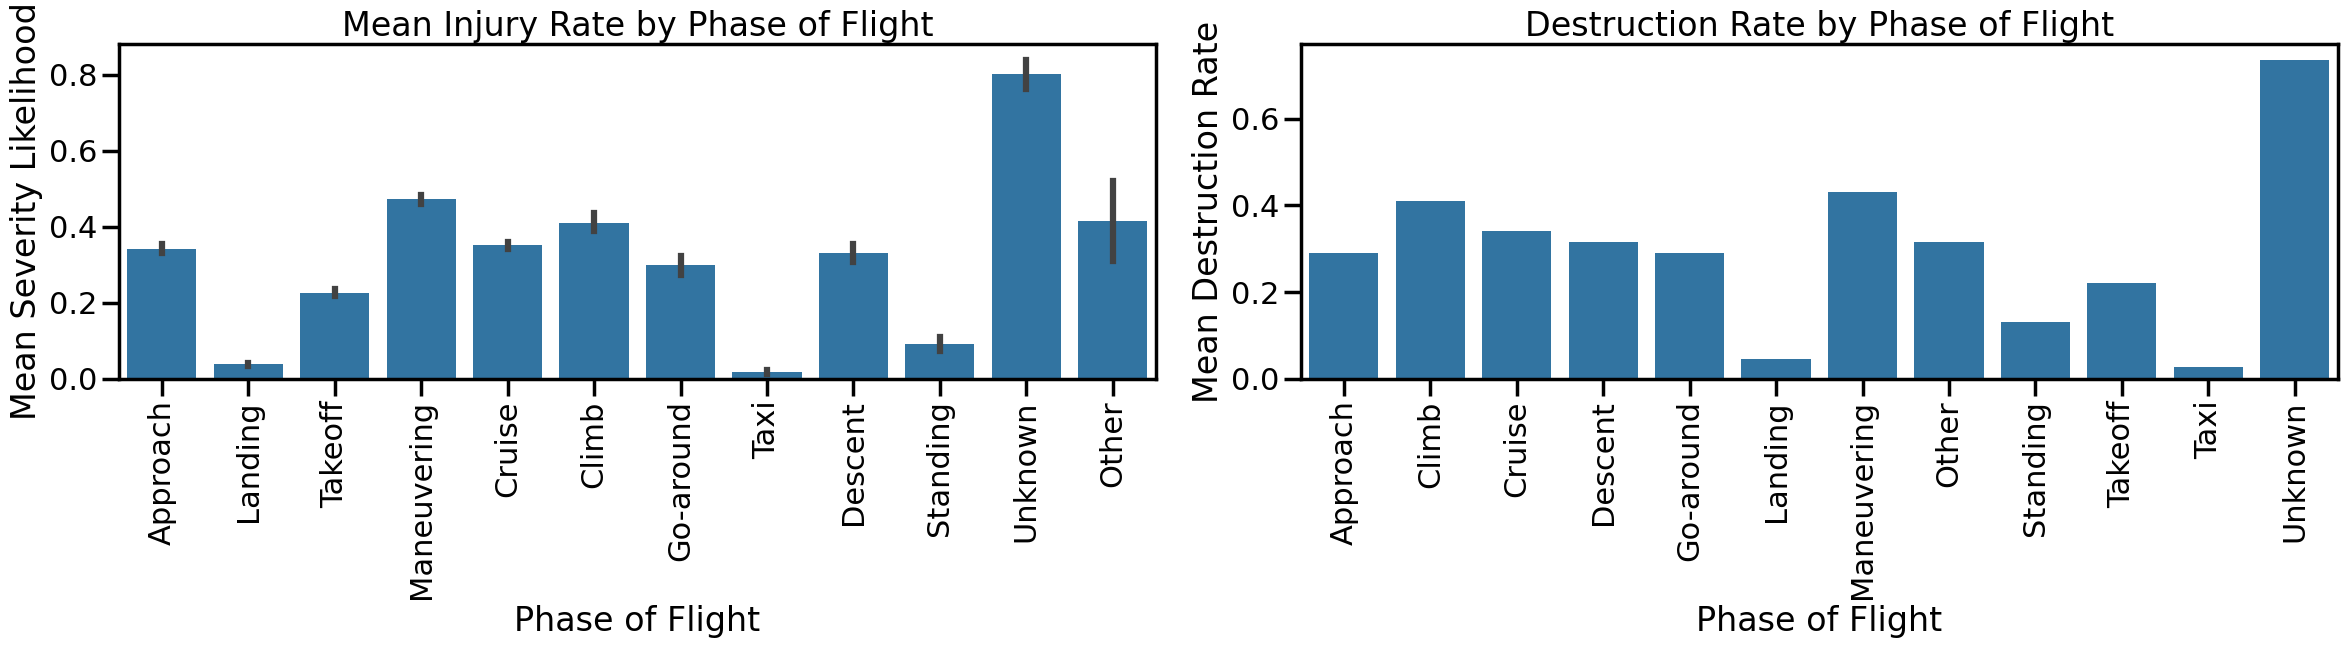

In [19]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 7))

sns.barplot(data=aviation_df, x="Broad.phase.of.flight", y="Severity.Likelihood",
        ax=ax1)
ax1.set(title="Mean Injury Rate by Phase of Flight",
        xlabel="Phase of Flight", ylabel="Mean Severity Likelihood")
ax1.tick_params(axis='x', rotation=90)

dest_by_phase = (aviation_df.groupby("Broad.phase.of.flight")["Aircraft.Destroyed"]
                 .mean())
sns.barplot(y=dest_by_phase.values, x=dest_by_phase.index, ax=ax2)
ax2.set(title="Destruction Rate by Phase of Flight",
        ylabel="Mean Destruction Rate", xlabel="Phase of Flight")
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**Phase of Flight: Findings**


- Maneuvering accidents show the highest injury severity rates.
- Approach and landing have a high absolute number of accidents but moderate mean severity.
- Taxi accidents predictably show near-zero injury rates, as ground collisions at low speed rarely cause passenger harm.
- Cruise-phase accidents can be severe when they do occur.